In [10]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.scorer import Scorer
from src.statistical_analysis import CausalEffectAnalyzer

In [11]:
countries = ['China', 'Spain', 'Greece', 'Indonesia', 'Algeria']

rows_cka = []
rows_tce = []
rows_ttests = []

In [ ]:
for country in countries:
    df = pd.read_csv(f'data/outputs/{country}_outputs.csv')
    df['en_answer_valid'] = df['en_answer_valid'].apply(ast.literal_eval)
    df['local_answer_valid'] = df['local_answer_valid'].apply(ast.literal_eval)

    scorer = Scorer()

    df_scores = scorer.scores_batch(df)
    analyzer = CausalEffectAnalyzer(df_scores)


    rows_cka.append({'country': country, 'group': 'control', 'cka': analyzer.compute_cka('control')})
    rows_cka.append({'country': country, 'group': 'persona', 'cka': analyzer.compute_cka('persona')})
    rows_cka.append({'country': country, 'group': 'language', 'cka': analyzer.compute_cka('language')})


    rows_tce.append({'country': country, 'group': 'persona', 'tce': analyzer.compute_tce('persona')})
    rows_tce.append({'country': country, 'group': 'language', 'tce': analyzer.compute_tce('language')})

    t_val_persona, p_val_persona = analyzer.t_tests('persona', country)
    t_val_lang, p_val_lang = analyzer.t_tests('language', country)

    rows_ttests.append({'country': country, 'group': 'persona', 't_val': t_val_persona, 'p_val': p_val_persona})
    rows_ttests.append({'country': country, 'group': 'language', 't_val': t_val_lang, 'p_val': p_val_lang})



China | persona | t = 0.573 | p = 0.567 | NO SIGNIFICANT STATISTICAL DIFFERENCE
China | language | t = 4.078 | p = 0.000 | SIGNIFICANT STATISTICAL DIFFERENCE
Spain | persona | t = 0.127 | p = 0.899 | NO SIGNIFICANT STATISTICAL DIFFERENCE
Spain | language | t = 2.920 | p = 0.004 | SIGNIFICANT STATISTICAL DIFFERENCE
Greece | persona | t = -0.389 | p = 0.697 | NO SIGNIFICANT STATISTICAL DIFFERENCE
Greece | language | t = -0.129 | p = 0.897 | NO SIGNIFICANT STATISTICAL DIFFERENCE
Indonesia | persona | t = -0.823 | p = 0.411 | NO SIGNIFICANT STATISTICAL DIFFERENCE
Indonesia | language | t = 3.377 | p = 0.001 | SIGNIFICANT STATISTICAL DIFFERENCE
Algeria | persona | t = -0.723 | p = 0.470 | NO SIGNIFICANT STATISTICAL DIFFERENCE
Algeria | language | t = -2.342 | p = 0.019 | SIGNIFICANT STATISTICAL DIFFERENCE


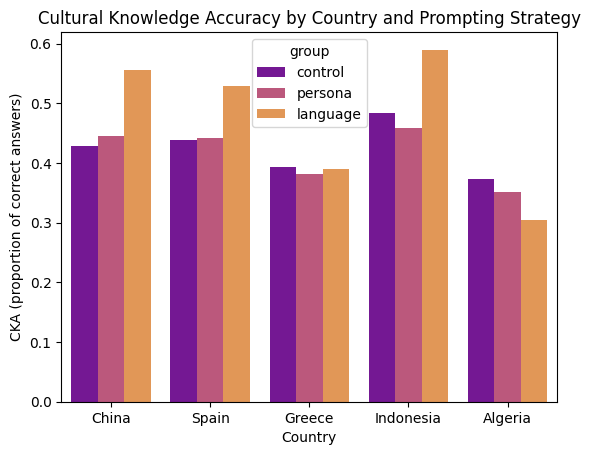

In [16]:
df_cka = pd.DataFrame(rows_cka)

sns.barplot(data=df_cka, x='country', y='cka', hue='group', palette = 'plasma')
plt.title('Cultural Knowledge Accuracy by Country and Prompting Strategy')
plt.xlabel('Country')
plt.ylabel('CKA (proportion of correct answers)')

os.makedirs('data/scores', exist_ok=True)
df_cka.to_csv(f'data/scores/CKA_scores.csv', index = False)


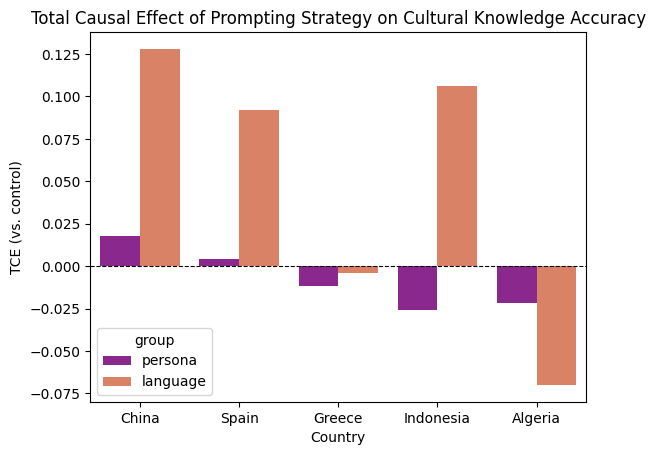

In [ ]:
df_tce = pd.DataFrame(rows_tce)
sns.barplot(data=df_tce, x='country', y='tce', hue='group', palette = 'plasma')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Total Causal Effect of Prompting Strategy on Cultural Knowledge Accuracy')
plt.xlabel('Country')
plt.ylabel('TCE (vs. control)')

df_tce.to_csv(f'data/scores/TCE_scores.csv', index = False)

In [8]:
df_ttest = pd.DataFrame(rows_ttests)
df_ttest['significant'] = df_ttest['p_val'] <= 0.05

df_ttest.to_csv(f'data/scores/t_tests.csv', index = False)

df_ttest.head(10)

,country,group,t_val,p_val,significant
0,China,persona,0.573303,0.566569,False
1,China,language,4.077735,0.000049,True
2,Spain,persona,0.127285,0.898740,False
3,Spain,language,2.920271,0.003576,True
4,Greece,persona,-0.389007,0.697354,False
5,Greece,language,-0.129421,0.897051,False
6,Indonesia,persona,-0.823034,0.410685,False
7,Indonesia,language,3.376998,0.000761,True
8,Algeria,persona,-0.722851,0.469941,False
9,Algeria,language,-2.342195,0.019367,True
